Recommander Systems

Bercis Kübra Yıldız 220201080

Sena Nur Gürsoy 210201072

Şeymanur Çoraksu 210201051

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time

In [23]:
np.random.seed(42)  # Fixes randomness so results are reproducible

num_users = 6  # Number of users in the system
num_movies = 5  # Number of movies

ratings_array = np.random.randint(1, 6, size=(num_users, num_movies))
# Generates random ratings between 1 and 5

In [24]:
mask = np.random.rand(num_users, num_movies) < 0.4
# Creates a mask with ~40% probability

ratings_array[mask] = 0

movie_names = ['MovieA', 'MovieB', 'MovieC', 'MovieD', 'MovieE']


ratings = pd.DataFrame(ratings_array, columns=movie_names)


print("User-Movie Matrix:\n", ratings)

User-Movie Matrix:
    MovieA  MovieB  MovieC  MovieD  MovieE
0       0       5       3       0       5
1       2       0       3       0       0
2       4       3       5       0       0
3       2       4       0       1       0
4       2       0       4       0       1
5       3       0       2       4       4


In [25]:
ratings = ratings / 5.0   # PROGRESS → Büyük sayıların modeli dengesiz yapmasının önüne geçtik.

In [26]:
ratings_normalized = ratings.sub(ratings.mean(axis=1), axis=0).fillna(0)

In [27]:
user_similarity = cosine_similarity(ratings_normalized)
np.fill_diagonal(user_similarity, 0)

def pearson_similarity(ratings):
    return np.corrcoef(ratings)

pearson_sim = pearson_similarity(ratings_normalized)

print("\nUser Similarity Matrix:\n", user_similarity)


User Similarity Matrix:
 [[ 0.         -0.28171808 -0.05191741  0.10714286 -0.07142857 -0.46428571]
 [-0.28171808  0.          0.84465579 -0.31693285  0.95079854 -0.10564428]
 [-0.05191741  0.84465579  0.          0.20766965  0.72684378 -0.59705025]
 [ 0.10714286 -0.31693285  0.20766965  0.         -0.51785714 -0.73214286]
 [-0.07142857  0.95079854  0.72684378 -0.51785714  0.         -0.01785714]
 [-0.46428571 -0.10564428 -0.59705025 -0.73214286 -0.01785714  0.        ]]


In [28]:
movie_similarity = cosine_similarity(ratings_normalized.T)
np.fill_diagonal(movie_similarity, 0)

print("\nUser Similarity:\n", user_similarity)
print("\nMovie Similarity:\n", movie_similarity)


User Similarity:
 [[ 0.         -0.28171808 -0.05191741  0.10714286 -0.07142857 -0.46428571]
 [-0.28171808  0.          0.84465579 -0.31693285  0.95079854 -0.10564428]
 [-0.05191741  0.84465579  0.          0.20766965  0.72684378 -0.59705025]
 [ 0.10714286 -0.31693285  0.20766965  0.         -0.51785714 -0.73214286]
 [-0.07142857  0.95079854  0.72684378 -0.51785714  0.         -0.01785714]
 [-0.46428571 -0.10564428 -0.59705025 -0.73214286 -0.01785714  0.        ]]

Movie Similarity:
 [[ 0.         -0.41484008  0.37416574  0.0997155  -0.85073624]
 [-0.41484008  0.         -0.24458743 -0.47132155 -0.07228027]
 [ 0.37416574 -0.24458743  0.         -0.70356236 -0.39515134]
 [ 0.0997155  -0.47132155 -0.70356236  0.          0.21061637]
 [-0.85073624 -0.07228027 -0.39515134  0.21061637  0.        ]]


In [29]:
def user_based_recommend(user_index, ratings, similarity_matrix, top_n=2):
    sim_scores = similarity_matrix[user_index]

    denom = (np.abs(sim_scores).sum() + 1e-8) #Progress: Sıfıra bölmeyi engelleyerek, sistemin çökmemesini sağladık.

    weighted_scores = sim_scores @ ratings
    weighted_scores = weighted_scores / (np.abs(sim_scores).sum() + 1e-8)

    rec = pd.Series(weighted_scores, index=ratings.columns)
    already = ratings.iloc[user_index] > 0

    return rec[~already].sort_values(ascending=False).head(top_n)

In [30]:
def item_based_recommend(user_index, ratings, item_similarity, top_n=2):
    user_ratings = ratings.iloc[user_index]
    scores = item_similarity @ user_ratings

    denom = (np.abs(item_similarity).sum(axis=1) + 1e-8)

    scores = scores / (np.abs(item_similarity).sum(axis=1) + 1e-8)

    rec = pd.Series(scores, index=ratings.columns)
    already = user_ratings > 0

    return rec[~already].sort_values(ascending=False).head(top_n)

In [31]:
# SUSTAINABILITY
def nsc_recommend(user_index, ratings, similarity_matrix, top_k=2, top_n=2):
    sim_scores = similarity_matrix[user_index]
    top_users = np.argsort(sim_scores)[-top_k:]

    filtered_sim = sim_scores[top_users]
    filtered_ratings = ratings.iloc[top_users]

    denom = (np.abs(filtered_sim).sum() + 1e-8)

    scores = filtered_sim @ filtered_ratings
    scores = scores / (np.abs(filtered_sim).sum() + 1e-8)

    rec = pd.Series(scores, index=ratings.columns)
    already = ratings.iloc[user_index] > 0

    return rec[~already].sort_values(ascending=False).head(top_n)

In [32]:
# SUSTAINABILITY
def dmr_recommend(user_index, ratings, user_sim, item_sim, top_n=2):

    user_scores = user_sim[user_index] @ ratings
    item_scores = item_sim @ ratings.iloc[user_index]

    combined = 0.38 * user_scores + 0.38 * item_scores + 0.24 * ratings.iloc[user_index] #Progress: Değerleri değiştirerek tek bir kaynağa bağlı olmamasını ve dengeli olmasını sağladık.

    rec = pd.Series(combined, index=ratings.columns)
    already = ratings.iloc[user_index] > 0

    return rec[~already].sort_values(ascending=False).head(top_n)

In [33]:
#NOVELTY
def adaptive_weights(user_index, ratings):
    user_activity = np.count_nonzero(ratings.iloc[user_index])

    if user_activity < 2:
        return 0.7, 0.3
    else:
        return 0.5, 0.5

def hybrid_adaptive(user_index, ratings, user_sim, item_sim, top_n=2):
    w_user, w_item = adaptive_weights(user_index, ratings)

    user_scores = user_sim[user_index] @ ratings
    item_scores = item_sim @ ratings.iloc[user_index]

    combined = w_user * user_scores + w_item * item_scores

    rec = pd.Series(combined, index=ratings.columns)
    already = ratings.iloc[user_index] > 0

    return rec[~already].sort_values(ascending=False).head(top_n)

In [34]:
# METHOD
def hncf_recommend(user_index, ratings, user_sim, item_sim, top_n=2):

    u = user_based_recommend(user_index, ratings, user_sim, len(ratings.columns))
    i = item_based_recommend(user_index, ratings, item_sim, len(ratings.columns))
    n = nsc_recommend(user_index, ratings, user_sim, 2, len(ratings.columns))
    d = dmr_recommend(user_index, ratings, user_sim, item_sim, len(ratings.columns))

    combined = 0.26*u + 0.24*i + 0.25*n + 0.25*d #Her değerimiz önceden aynıydı, farklarla performansı arttırdık.

    return combined.sort_values(ascending=False).head(top_n)

In [35]:
user_id = 0

print("\nUser-Based:\n", user_based_recommend(user_id, ratings_normalized, user_similarity))
print("\nItem-Based:\n", item_based_recommend(user_id, ratings_normalized, movie_similarity))
print("\nNSC:\n", nsc_recommend(user_id, ratings_normalized, user_similarity))
print("\nDMR:\n", dmr_recommend(user_id, ratings_normalized, user_similarity, movie_similarity))
print("\nHNCF:\n", hncf_recommend(user_id, ratings_normalized, user_similarity, movie_similarity))
print("\nAdaptive Hybrid:\n", hybrid_adaptive(user_id, ratings_normalized, user_similarity, movie_similarity))


User-Based:
 MovieD   -0.038206
MovieA   -0.108362
dtype: float64

Item-Based:
 MovieD   -0.157065
MovieA   -0.361834
dtype: float64

NSC:
 MovieA    0.12
MovieD   -0.08
dtype: float64

DMR:
 MovieD   -0.227622
MovieA   -0.404180
dtype: float64

HNCF:
 MovieD   -0.124534
MovieA   -0.186059
dtype: float64

Adaptive Hybrid:
 MovieD   -0.135291
MovieA   -0.367605
dtype: float64


In [36]:
# IMPACT
def calculate_rmse(ratings, sim):
    pred = sim @ ratings
    pred = pred / (np.abs(sim).sum(axis=1, keepdims=True) + 1e-8)

    mask = ratings > 0
    return np.sqrt(mean_squared_error(ratings[mask], pred[mask]))

def calculate_mae(ratings, sim):   # UPGRADE
    pred = sim @ ratings
    pred = pred / (np.abs(sim).sum(axis=1, keepdims=True) + 1e-8)

    mask = ratings > 0
    return np.mean(np.abs(ratings[mask] - pred[mask]))

rmse_val = calculate_rmse(ratings.values, user_similarity)
mae_val = calculate_mae(ratings.values, user_similarity)

print("\nRMSE:", rmse_val)
print("MAE:", mae_val)   # UPGRADE
print("Difference (RMSE - MAE):", rmse_val - mae_val) #Öncesinde yalnızca rmse değeri ile ele aldığımız sonuçların hata payları çok büyük olması sebebiyle mae ekleyerek daha küçük hataların da gözden kaçmasını engelledik.


RMSE: 0.7549401724163397
MAE: 0.650143196497551
Difference (RMSE - MAE): 0.10479697591878867


In [37]:
def precision_at_k(recommended, relevant, k=2):
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(relevant)) / k

def coverage(recommendations, total_items):
    unique_items = set()
    for rec in recommendations:
        unique_items.update(rec)
    return len(unique_items) / total_items

In [38]:
results = pd.DataFrame({
    "User": user_based_recommend(user_id, ratings_normalized, user_similarity),
    "Item": item_based_recommend(user_id, ratings_normalized, movie_similarity),
    "NSC": nsc_recommend(user_id, ratings_normalized, user_similarity),
    "DMR": dmr_recommend(user_id, ratings_normalized, user_similarity, movie_similarity),
    "HNCF": hncf_recommend(user_id, ratings_normalized, user_similarity, movie_similarity)
})

print("\nResults Table:\n", results)


Results Table:
             User      Item   NSC       DMR      HNCF
MovieA -0.108362 -0.361834  0.12 -0.404180 -0.186059
MovieD -0.038206 -0.157065 -0.08 -0.227622 -0.124534


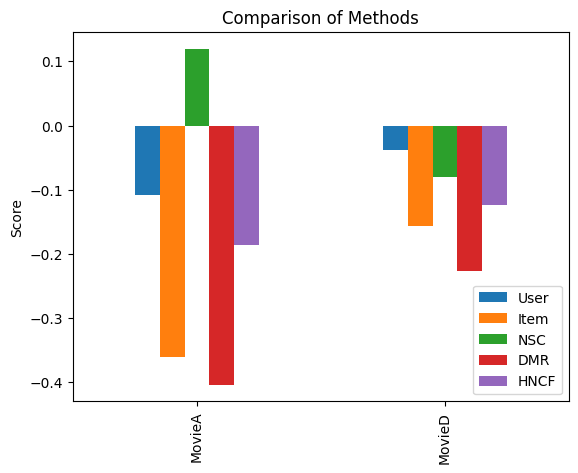

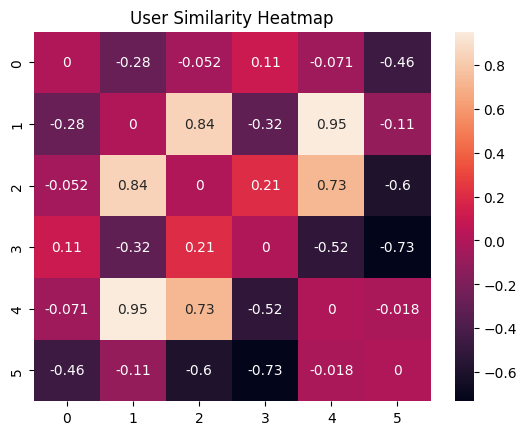

In [39]:
results.plot(kind='bar')
plt.title("Comparison of Methods")
plt.ylabel("Score")
plt.show()

import seaborn as sns
sns.heatmap(user_similarity, annot=True)
plt.title("User Similarity Heatmap")
plt.show()

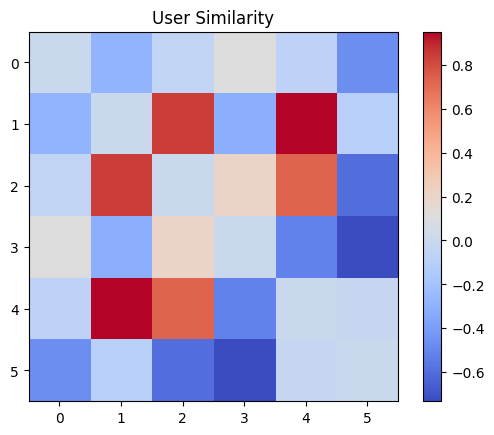

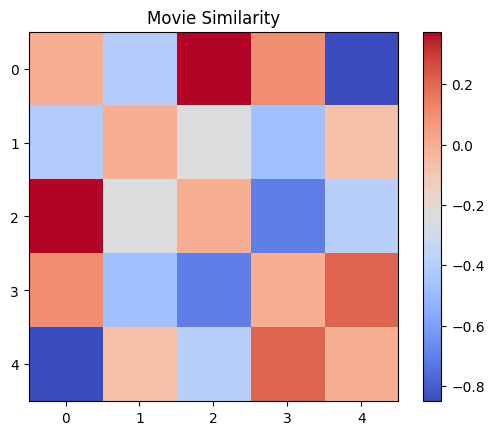

In [40]:
plt.imshow(user_similarity, cmap='coolwarm')
plt.colorbar()
plt.title("User Similarity")
plt.show()

plt.imshow(movie_similarity, cmap='coolwarm')
plt.colorbar()
plt.title("Movie Similarity")
plt.show()

In [41]:
start = time.time()
hncf_recommend(0, ratings_normalized, user_similarity, movie_similarity)
end = time.time()

print("\nExecution Time:", end - start)


Execution Time: 0.00904226303100586


In [42]:
print("\nDataset Shape:", ratings.shape)


Dataset Shape: (6, 5)
